In [54]:
import attrs
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import copy
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import torchvision

In [55]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            # 1
            nn.Conv2d(
                in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2
            ),  # 28*28->32*32-->28*28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 14*14
            # 2
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),  # 10*10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 5*5
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=16 * 5 * 5, out_features=60),
            nn.Tanh(),
            nn.Linear(in_features=60, out_features=42),
            nn.Tanh(),
        )
        self.Bob = nn.Sequential(
            nn.Linear(in_features=42, out_features=10),
        )

    def forward(self, x):
        z = self.classifier(self.feature(x))
        out = self.Bob(z)
        return out, z

model = LeNet()
model.load_state_dict(torch.load("../../checkpoints/mnist_example.pth", weights_only=True))

<All keys matched successfully>

In [56]:
train_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,)),
    ]
)
rnd_perm = np.random.permutation(np.arange(0, 60000))
full_trainset = torchvision.datasets.MNIST(
    "../../data", train=True, download=True, transform=train_transform
)
# The same one from the src/zo_dynamics/mnist_example.py
np.random.seed(12345)
train_subset = torch.utils.data.Subset(full_trainset, list(rnd_perm[:20000]))
test_subset = torch.utils.data.Subset(full_trainset, list(rnd_perm[20000:40000]))

seed_loader = torch.utils.data.DataLoader(train_subset, batch_size=2000, shuffle=False)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=2000, shuffle=False)

In [57]:
def calc_jacobian_z(z, model):
    params = list(model.parameters())
    num_outputs = z.shape[1]
    jacobian_rows = []

    for i in range(num_outputs):
        # Calculate the gradients for z[0, i] w.r.t. all params.
        # This returns a tuple of gradients, one for each param.
        grad_tuple = torch.autograd.grad(
            outputs=z[0, i],          # The scalar output element
            inputs=params,            # The parameters you want gradients for
            retain_graph=True,        # Must keep graph for next loop iteration
            allow_unused=True         # Some params might not contribute to the output
        )
        
        # Flatten and concatenate the gradients into a single row vector
        grad_row = torch.cat([g.flatten() for g in grad_tuple if g is not None])
        jacobian_rows.append(grad_row)

    # Stack all rows to get the Jacobian
    jacobian = torch.stack(jacobian_rows)
    return jacobian

In [58]:
from util.metrics import Metric

DEVICE = "mps"
model.to(DEVICE)
model.eval()
with torch.no_grad():
    test_loss = Metric("Test loss")
    test_acc = Metric("Test acc")
    for data_iter_step, (x, y) in enumerate(test_loader):
        x, y = x.float().to(DEVICE), y.long().to(DEVICE)
        outputs, z = model(x)
        loss = nn.CrossEntropyLoss()(outputs, y)
        test_loss.update(loss.item())
        test_acc.update((outputs.argmax(dim=1) == y).sum().item())

In [59]:
def plot_ntk(idx1, idx2, seed: int | None, num_pert: int):
    data1, label1 = train_subset[idx1]
    data2, label2 = test_subset[idx2]
    fig, ax = plt.subplots(2, 2, figsize=(6, 5))
    ax[0][0].imshow(data1[0, :].squeeze())
    ax[0][0].set_title(f"label={label1}")
    ax[0][1].imshow(data2[0, :].squeeze())
    ax[0][1].set_title(f"label={label2}")
    
    output1, z = model(torch.unsqueeze(data1, dim=0).float().to(DEVICE))
    output2, z = model(torch.unsqueeze(data2, dim=0).float().to(DEVICE))
    jacobian1 = calc_jacobian_z(output1, model)
    jacobian2 = calc_jacobian_z(output2, model)
    
    im1 = ax[1][0].imshow((jacobian1 @ jacobian2.T).cpu())
    fig.colorbar(im1, ax=ax[1][0])

    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)
    u = torch.normal(mean=0, std=1, size=(num_pert, jacobian1.shape[1])).to(DEVICE)
    im2 = ax[1][1].imshow((jacobian1 @ u.T @ u @ jacobian2.T).cpu() / num_pert)
    fig.colorbar(im2, ax=ax[1][1]) 

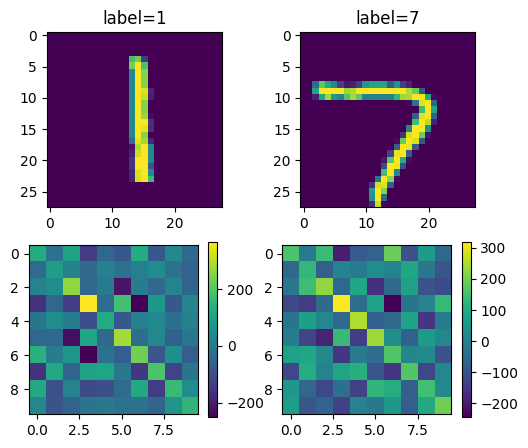

In [63]:
plot_ntk(125, 110, seed=1223, num_pert=120)

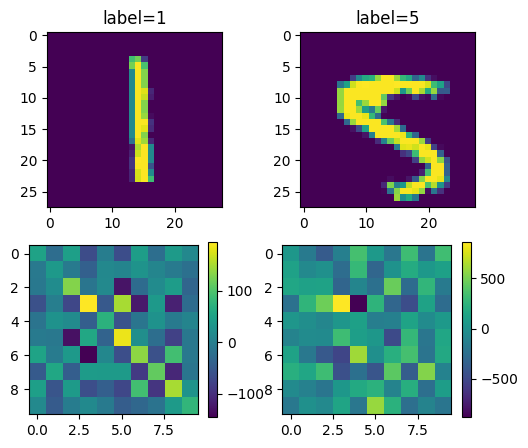

In [62]:
plot_ntk(125, 130, seed=1223, num_pert=10)

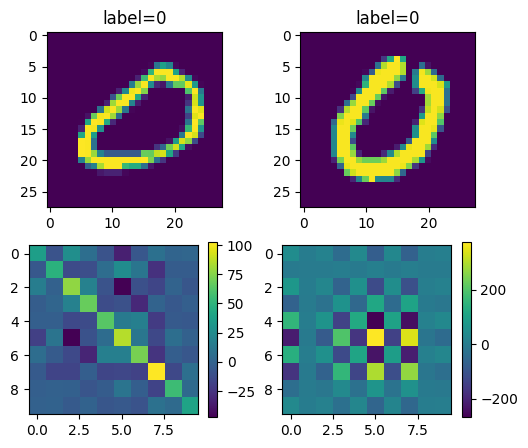

In [52]:
plot_ntk(125, 130, seed=1223, num_pert=1)

In [38]:
seed = 12345
num_pert = 2000
d = 1000

rng = np.random.default_rng(seed=seed)
u = rng.normal(size=(num_pert, d)).astype(np.float32) / np.sqrt(num_pert)

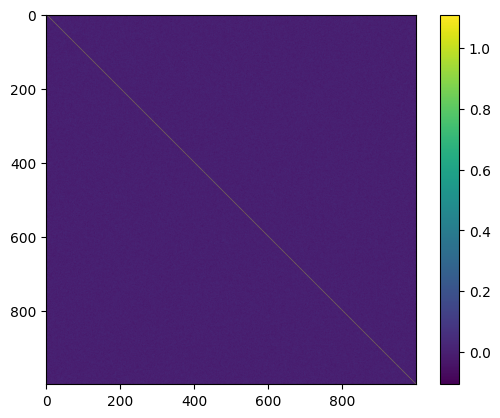

In [39]:
plt.imshow(u.T @ u)
plt.colorbar()

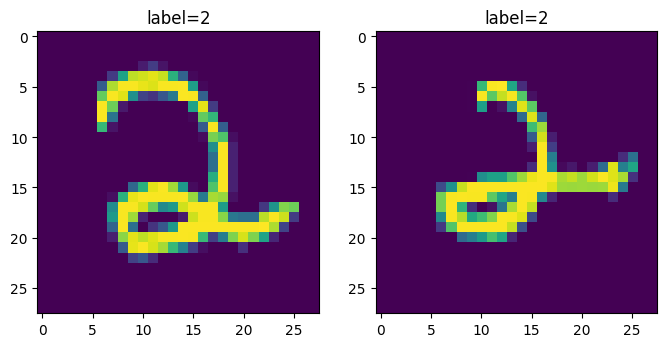

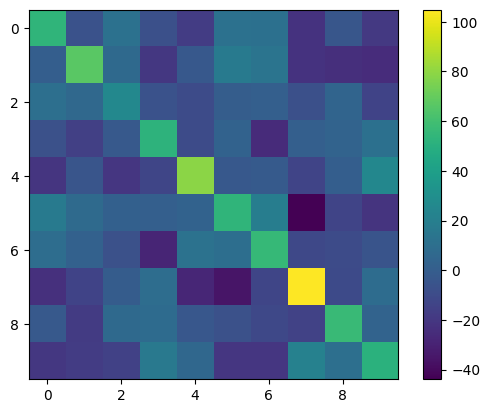

In [129]:
plot_ntk(124,412)

In [87]:
def show_image(data, label):
    output, z = model(torch.unsqueeze(data, dim=0).float().to(DEVICE))
    y = F.softmax(output, dim=1).cpu().detach().numpy().squeeze()
    
    fig, ax = plt.subplots(1,2, figsize=(8, 3))
    ax[0].imshow(data[0, :].squeeze())
    ax[1].step(x=np.arange(len(y)) + 1, y=y)
    ax[1].annotate(f"{label=}", xy=(label+0.5, 0.8), xytext=(label+0.5, 0.9), arrowprops=dict(arrowstyle="simple",color='darkred',),
                      horizontalalignment='center',color='darkred',fontsize=16)
    ax[1].set_xlim(-0.5, 10)

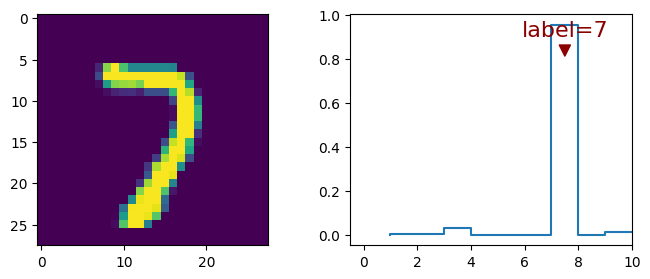

In [92]:
show_image(*test_subset[627])

In [ ]:
model.eval()
x, y = test_subset[3]


In [47]:
F.softmax(output, dim=1).cpu().detach().numpy()

array([[1.1422330e-04, 2.6217481e-04, 6.0258015e-05, 1.0133449e-03,
        4.0763032e-04, 2.3966320e-04, 1.3036135e-05, 9.7347426e-01,
        5.6776119e-04, 2.3847617e-02]], dtype=float32)

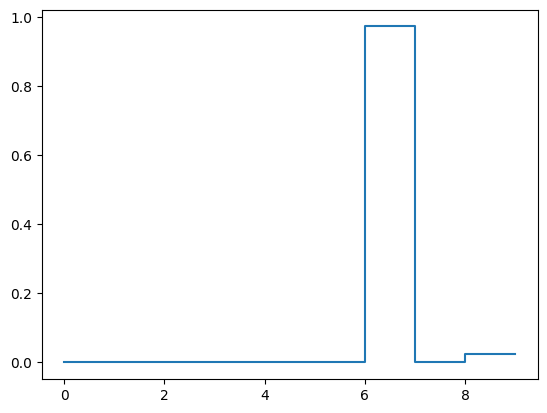

In [ ]:
from zo_llm import zo_optim
from zo_llm import perturb 

In [23]:
@attrs.mutable
class Config:
    lr: float = 1e-4
    device: str = DEVICE
    num_pert: int = 5
    pert_distribution: str = "gaussian"
    mu = 1e-4
    
config = Config()
opt = zo_optim.ZOOptimizer.from_config(config, model)